# 電商顧客分群分析：以 RFM 模型制定行銷策略

### 專案概述
本專案針對某英國線上零售商的真實交易數據（Online Retail II，2009–2011），
透過 **RFM 模型**進行顧客分群。原始數據約 105 萬筆交易，
經清理後保留約 80 萬筆有效交易，目標是回答一個關鍵商業問題：

> **「行銷預算有限時，該優先把錢花在哪一群顧客身上？」**

### 核心發現
- 📊 **營收高度集中**：25.2% 的「最佳客戶」貢獻了 69.3% 的總營收，
  平均購買頻率高達 15.7 次，是高黏著的死忠客群。
- 🎯 **鎖定高 ROI 召回對象**：識別出佔 14% 的「重點召回」客群，
  他們曾有 4.9 次購買紀錄（證實過的忠誠度），
  是行銷投報率最高的再行銷目標。
- 💡 **策略建議**：區分「暫時性流失」與「結構性流失」，
  優先投入預算於前者，避免浪費資源在低忠誠的一次性顧客。



### 分析方法
1. **資料清理**：篩選有效交易（排除退貨、測試單、缺失顧客 ID）
2. **RFM 計算**：Recency（最近購買）、Frequency（購買次數）、Monetary（累積消費金額）
3. **分群評分**：以 `pd.qcut` 五分位數評分，切分出 6 大顧客群
4. **策略轉化**：將數據洞察轉為可執行的行銷行動方案

### 技術棧
`Python` · `Pandas` · `NumPy` · `Matplotlib` · `Tableau`

### 🔗 互動式儀表板
> 完整互動視覺化請見 [Tableau Public 連結](https://public.tableau.com/app/profile/.25094516/viz/RFMCustomerSegmentationAnalysis_17832676637400/1)


In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
df = pd.read_csv(r'C:\Users\USER\Desktop\kaggle\online_retail_II.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [2]:
df_rfm = df[
    (df['Quantity'] > 0) &
    (~df['Invoice'].astype(str).str.startswith('C')) &
    (df['Customer ID'].notna()) &
    (df['Price'] > 0) &
    (~df['StockCode'].astype(str).str.contains('TEST', case=False, na=False))
].copy() 

snapshot_date = df_rfm['InvoiceDate'].max() + pd.Timedelta(days=1)

df_rfm['TotalPrice'] = df_rfm['Quantity'] * df_rfm['Price']

rfm = df_rfm.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('TotalPrice', 'sum')
).reset_index()


# RFM Scoring R：越近越好 → 分數反轉（labels 由大到小）F M越大越好
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])

# F、M：越大越好 → 正常給分
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])


rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

# rfm相加 用分數分群 讓他變成 "115"分別是rfm的分數
rfm['rfm_group'] = (
    rfm['R_Score'].astype(str) + 
    rfm['F_Score'].astype(str)+
    rfm['M_Score'].astype(str)
)
# RFM 總分（用來看整體價值排名）
rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

print(rfm.head())

   Customer ID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0      12346.0      326          3  77352.96        2        3        5   
1      12347.0        2          8   5633.32        5        4        5   
2      12348.0       75          5   2019.40        3        4        4   
3      12349.0       19          4   4428.69        5        3        5   
4      12350.0      310          1    334.40        2        1        2   

  rfm_group  RFM_Score  
0       235         10  
1       545         14  
2       344         11  
3       535         13  
4       212          5  


In [3]:
def segment_customer(row):
    r, f = row['R_Score'], row['F_Score']

    if r >= 4 and f >= 4:
        return '最佳客戶'      
    elif r >= 3 and f >= 3:
        return '穩定回購'    
    elif r >= 4 and f <= 2:
        return '新客戶'      
    elif r >= 3 and f <= 2:
        return '有潛力培養' 
    elif r <= 2 and f >= 3:
        return '重點召回'            
    elif r <= 2 and f <= 2:
        return '快流失/已流失'        
    else:
        return '其他'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)


segment_summary = rfm.groupby('Segment').agg(
    客戶數=('Customer ID', 'count'),
    平均Recency=('Recency', 'mean'),
    平均Frequency=('Frequency', 'mean'),
    平均Monetary=('Monetary', 'mean'),
    總營收貢獻=('Monetary', 'sum'),
).round(1).sort_values('總營收貢獻', ascending=False)

total_customers = rfm['Customer ID'].nunique()
total_revenue   = rfm['Monetary'].sum()

segment_summary['人數占比%']   = (segment_summary['客戶數'] / total_customers * 100).round(1)
segment_summary['營收占比%']   = (segment_summary['總營收貢獻'] / total_revenue * 100).round(1)

segment_summary

,客戶數,平均Recency,平均Frequency,平均Monetary,總營收貢獻,人數占比%,營收占比%
Segment,,,,,,,
最佳客戶,1481,20.4,15.7,8300.5,12293107.7,25.2,69.3
穩定回購,1222,78.5,5.4,2085.9,2548946.1,20.8,14.4
重點召回,824,369.1,4.9,1982.7,1633772.0,14.0,9.2
快流失/已流失,1523,459.3,1.3,438.0,667121.9,25.9,3.8
新客戶,443,28.1,1.5,890.8,394638.6,7.5,2.2
有潛力培養,385,107.1,1.4,534.1,205616.8,6.5,1.2


## 🔍 帕累托分析：營收集中度檢驗

**商業問題**：營收是否集中在少數客戶身上？若是，行銷資源該如何分配？

**方法**：將清洗後的交易資料按 `Customer ID` 聚合總營收，繪製 Lorenz Curve，
並與「絕對平均線」(45度線) 對比，觀察營收集中程度。

**核心發現**：僅 **20%** 的客戶貢獻了 **77.2%** 的營收，符合帕累托法則。



前 20% 客戶貢獻了 77.2% 的營收


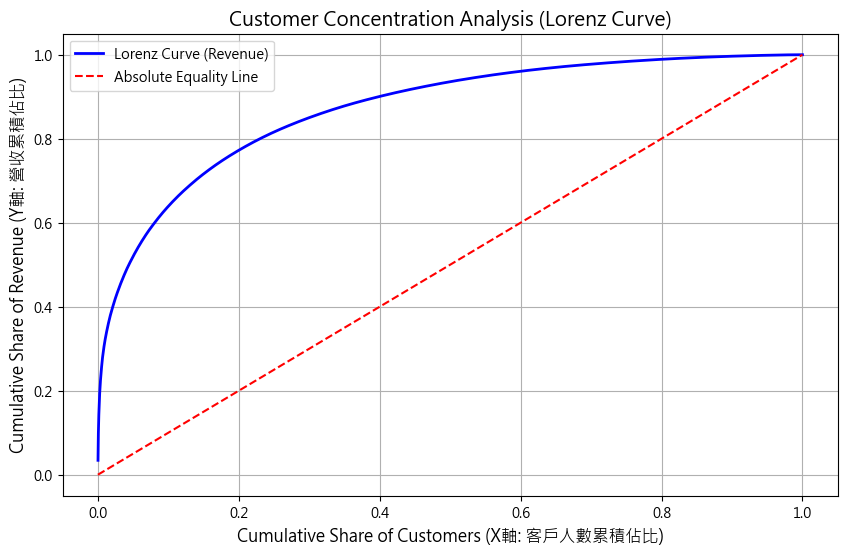

In [4]:
import numpy as np
#現在要進行帕累托法則 20%客戶 80%營收
df_customer = df_rfm[(df_rfm['Customer ID'].notna()) & (df_rfm['TotalPrice'] > 0)].copy()
df_customer_20 = df_customer.groupby('Customer ID')['TotalPrice'].sum().sort_values(ascending=False)
#營收占比
df_customer_percentage = df_customer_20.cumsum() / df_customer_20.sum()
# print(df_customer_percentage.head(5))

#前20%客戶累積營收
n = len(df_customer_percentage)
df_customer_cumsum = int(n * 0.2)
df_customer_cumsum_20_revenue = df_customer_percentage.iloc[df_customer_cumsum - 1]
print(f"前 20% 客戶貢獻了 {df_customer_cumsum_20_revenue:.1%} 的營收")

#畫出帕累托曲線圖
x = np.arange(1, n+1) / n
y = df_customer_percentage
import matplotlib.pyplot as plt

#Windows 系統（微軟正黑體）：
plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei"]
plt.rcParams["axes.unicode_minus"] = False 

plt.figure(figsize=(10, 6))
plt.plot(x, y, label = "Lorenz Curve (Revenue)", color = 'blue', linewidth=2)
# 畫一條 45 度的對角線（代表絕對平均：50%的人貢獻50%營收）作對比
plt.plot([0, 1], [0, 1], "r--", label="Absolute Equality Line")


plt.title("Customer Concentration Analysis (Lorenz Curve)", fontsize=14)
plt.xlabel("Cumulative Share of Customers (X軸: 客戶人數累積佔比)", fontsize=12)
plt.ylabel("Cumulative Share of Revenue (Y軸: 營收累積佔比)", fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

## 📊 結論與商業建議

### 核心發現：營收高度集中

透過 RFM 分群，我們發現客戶價值呈現高度集中的現象：

- **最佳客戶** 僅占 **25.2%** 的人數，卻貢獻了 **69.3%** 的營收。
- **快流失/已流失** 占 **25.9%** 的人數（人數最多），但僅貢獻 **3.8%** 的營收。
- 兩群人數相近，營收貢獻卻相差約 **18 倍**。
- 最佳客戶平均購買頻率高達 **15.7 次**，是「穩定回購」客群（5.4 次）的近 3 倍，
  顯示這群人不只貢獻高，更是**高黏著度的死忠客戶**。


> 這代表公司的營收命脈掌握在少數高價值客戶手中，行銷資源應**差異化配置**，而非齊頭式投放。

---

### 分群行動策略

| 分群 | 特徵 | 建議行動 | 優先級 |
|------|------|---------|:------:|
| **最佳客戶** | 高頻、近期、高消費（69% 營收） | VIP 專屬服務、新品優先體驗；**核心目標是「維繫」與避免流失** | 🔴 高 |
| **重點召回** | 曾高頻購買（平均 4.9 次），但已 369 天未回購 | 專屬折扣 + 召回 email；**投報率最高的目標** | 🔴 高 |
| **穩定回購** | 回購穩定的中堅客群 | 會員積分、交叉銷售，推動升級為最佳客戶 | 🟡 中 |
| **新客戶** | 剛完成首購（約 28 天內） | 新手引導、第二次購買誘因，建立回購習慣 | 🟡 中 |
| **有潛力培養** | 頻率偏低但仍有活動 | 輕度觸及、觀察後續行為 | 🟢 低 |
| **快流失/已流失** | 平均僅購買 1.3 次即流失 | 低成本自動化喚醒，**不投入高成本行銷** | 🟢 低 |

---

### 關鍵決策邏輯：為何優先召回「重點召回」而非「快流失」？

雖然「快流失」人數最多，但資源應優先投入「重點召回」，原因在於 **ROI 的取捨**：

- **重點召回**客戶平均購買達 **4.9 次**，代表他們**曾建立起真實的購買習慣與品牌認同**。其流失多為暫時性因素（如換供應商、遺忘），透過低成本的召回手段即有機會喚醒。
- **快流失**客戶平均僅購買 **1.3 次**，從未建立忠誠度，多為一次性比價或衝動購買。將其轉化為回頭客的成本，遠高於預期回報。

> **結論：召回一個「曾經的高價值客戶」，遠比教育一個「從未建立忠誠度的客戶」更具成本效益。**
